In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
from pathlib import Path

REPO_URL = "https://github.com/yehonatan768/Facial_Recognition.git"   # change
DEST_DIR = Path("/content/Face_Recognition")            # choose folder name

if DEST_DIR.exists():
    print("Repo folder already exists:", DEST_DIR)
else:
    !git clone {REPO_URL} {DEST_DIR}

%cd /content/Face_Recognition
!git status

Cloning into '/content/Face_Recognition'...
remote: Enumerating objects: 991, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 991 (delta 149), reused 136 (delta 104), pack-reused 794 (from 1)
Receiving objects: 100% (991/991), 4.93 MiB | 19.58 MiB/s, done.
Resolving deltas: 100% (595/595), done.
/content/Face_Recognition
On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean


In [3]:
!git checkout Sprint-3

Branch 'Sprint-3' set up to track remote branch 'Sprint-3' from 'origin'.
Switched to a new branch 'Sprint-3'


In [4]:
from pathlib import Path
import shutil

ZIP_ON_DRIVE = Path("/content/drive/MyDrive/Facial_Recognition/lfwa.zip")  # change if needed
ZIP_LOCAL = Path("/content/lfwa.zip")

shutil.copy2(ZIP_ON_DRIVE, ZIP_LOCAL)
print("Copied ZIP to local:", ZIP_LOCAL)

Copied ZIP to local: /content/lfwa.zip


In [5]:
import zipfile
from pathlib import Path
import shutil

ZIP_LOCAL = Path("/content/lfwa.zip")
IMAGES_DIR = Path("/content/Face_Recognition/images")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

prefix = "lfw2/lfw2/"

with zipfile.ZipFile(ZIP_LOCAL) as z:
    for member in z.namelist():
        if member.startswith(prefix) and not member.endswith("/"):
            rel = Path(member).parts[len(Path(prefix).parts):]
            out = IMAGES_DIR.joinpath(*rel)

            out.parent.mkdir(parents=True, exist_ok=True)
            with z.open(member) as src, open(out, "wb") as dst:
                shutil.copyfileobj(src, dst)

print("Extracted locally into:", IMAGES_DIR)

Extracted locally into: /content/Face_Recognition/images


In [6]:
!ls

assets	images	notebooks  plots  README.md  requirements.txt  src


In [7]:
!python -m src.run.train

2025-12-30 23:48:10,466 | INFO | train | Device: cuda
2025-12-30 23:48:19,808 | INFO | train | [Split] train pairs: n=1650 pos_frac=0.504 | val pairs: n=550 pos_frac=0.489 | target_val_pairs=550 target_pos_frac=0.50
2025-12-30 23:48:19,808 | INFO | train | [Split] train_ids=1772 | val_ids=360 | components=1032
2025-12-30 23:48:19,809 | INFO | train | Validation source: split_from_train (train_txt=/content/Face_Recognition/assets/pairsDevTrain.txt)
2025-12-30 23:48:19,810 | INFO | train | Loaded train pairs: 1650
2025-12-30 23:48:19,810 | INFO | train | Loaded val pairs: 550
2025-12-30 23:48:32,002 | INFO | train | Epoch 001/200 | loss: train=0.963294 val=0.705866 | acc: train=0.5168 val=0.5382 | lr=0.01000000 m=0.5080
2025-12-30 23:48:42,164 | INFO | train | Epoch 002/200 | loss: train=0.717428 val=0.672710 | acc: train=0.5595 val=0.5836 | lr=0.00985000 m=0.5160
2025-12-30 23:48:51,334 | INFO | train | Epoch 003/200 | loss: train=0.709616 val=0.701912 | acc: train=0.5613 val=0.5836 | l

Parsed 52 epochs from outputs/siamese_verification/train.log
Best val_loss epoch: 32 (val_loss=0.609072)
Best val_acc epoch:  43 (val_acc=0.681818)


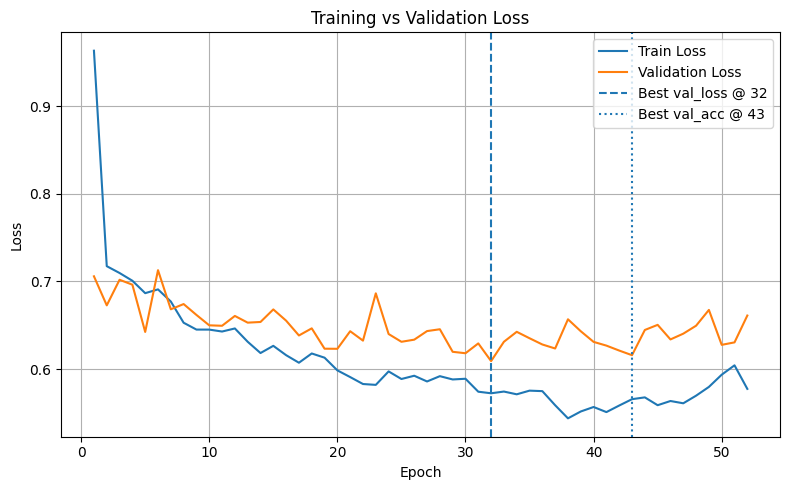

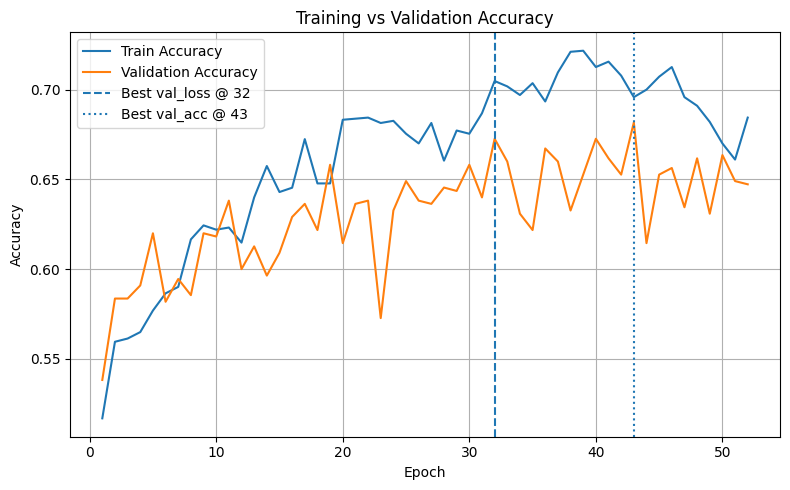

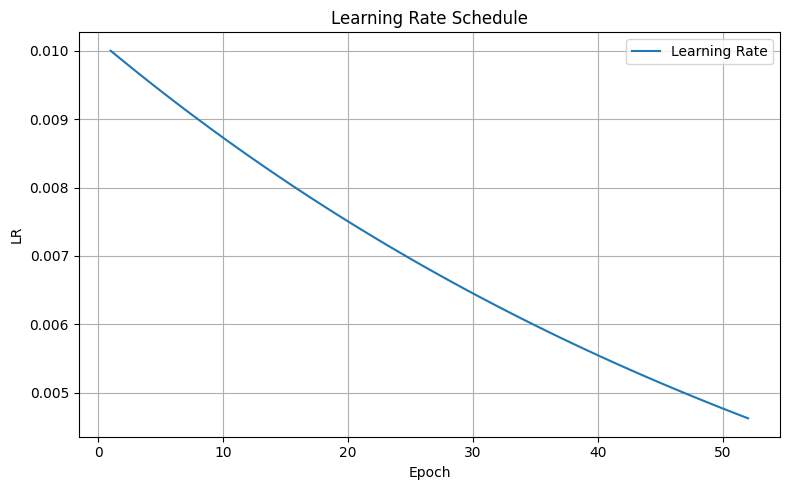

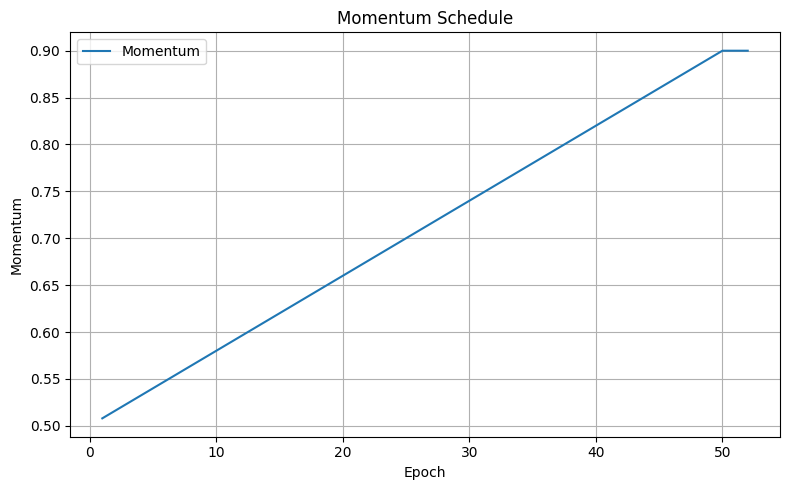

In [8]:
# =========================
# Plot curves from train.log
# =========================

import re
from pathlib import Path
import matplotlib.pyplot as plt

log_path = Path("outputs/siamese_verification/train.log")
assert log_path.exists(), f"Missing log: {log_path.resolve()}"

# --- regex for epoch lines ---
epoch_pat = re.compile(
    r"Epoch\s+(?P<ep>\d+)/\d+\s+\|\s+loss:\s+train=(?P<tl>[0-9.]+)\s+val=(?P<vl>[0-9.]+)\s+\|\s+"
    r"acc:\s+train=(?P<ta>[0-9.]+)\s+val=(?P<va>[0-9.]+)\s+\|\s+"
    r"lr=(?P<lr>[0-9.]+)\s+m=(?P<m>[0-9.]+)"
)

# --- regex for summary lines (optional) ---
best_loss_pat = re.compile(r"best\s+val_loss=(?P<best_vl>[0-9.]+)")
best_epoch_pat = re.compile(r"best\s+epoch=(?P<best_ep>\d+)")
best_acc_pat = re.compile(r"best_val_accuracy=(?P<best_va>[0-9.]+)")

epochs, tl, vl, ta, va, lrs, moms = [], [], [], [], [], [], []
best_loss_epoch = None
best_acc_epoch = None
best_val_loss = None
best_val_acc = None

with log_path.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        m = epoch_pat.search(line)
        if m:
            epochs.append(int(m.group("ep")))
            tl.append(float(m.group("tl")))
            vl.append(float(m.group("vl")))
            ta.append(float(m.group("ta")))
            va.append(float(m.group("va")))
            lrs.append(float(m.group("lr")))
            moms.append(float(m.group("m")))
            continue

        # capture best loss epoch from early stopping line if present
        if "Early stopping" in line:
            me = best_epoch_pat.search(line)
            ml = best_loss_pat.search(line)
            if me:
                best_loss_epoch = int(me.group("best_ep"))
            if ml:
                best_val_loss = float(ml.group("best_vl"))

        # capture best val accuracy epoch if present (your "Done." line)
        if "best_val_accuracy" in line:
            ma = best_acc_pat.search(line)
            if ma:
                best_val_acc = float(ma.group("best_va"))
            # also try to read "Best epoch=XX" from that same line
            me2 = re.search(r"Best\s+epoch=(\d+)", line)
            if me2:
                best_acc_epoch = int(me2.group(1))

assert len(epochs) > 0, "No epoch lines parsed. Check that log format matches the regex."

print(f"Parsed {len(epochs)} epochs from {log_path}")
if best_loss_epoch is not None:
    print(f"Best val_loss epoch: {best_loss_epoch} (val_loss={best_val_loss})")
if best_acc_epoch is not None:
    print(f"Best val_acc epoch:  {best_acc_epoch} (val_acc={best_val_acc})")

# -------------------------
# Plot Loss
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, tl, label="Train Loss")
plt.plot(epochs, vl, label="Validation Loss")

if best_loss_epoch is not None and best_loss_epoch in epochs:
    plt.axvline(best_loss_epoch, linestyle="--", label=f"Best val_loss @ {best_loss_epoch}")
if best_acc_epoch is not None and best_acc_epoch in epochs:
    plt.axvline(best_acc_epoch, linestyle=":", label=f"Best val_acc @ {best_acc_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# Plot Accuracy
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, ta, label="Train Accuracy")
plt.plot(epochs, va, label="Validation Accuracy")

if best_loss_epoch is not None and best_loss_epoch in epochs:
    plt.axvline(best_loss_epoch, linestyle="--", label=f"Best val_loss @ {best_loss_epoch}")
if best_acc_epoch is not None and best_acc_epoch in epochs:
    plt.axvline(best_acc_epoch, linestyle=":", label=f"Best val_acc @ {best_acc_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# (Optional) Plot LR & Momentum
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, lrs, label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, moms, label="Momentum")
plt.xlabel("Epoch")
plt.ylabel("Momentum")
plt.title("Momentum Schedule")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
